## <span style="color:blue"> Lezione 1 </span>



In [1]:

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### <span style="color:DodgerBlue"> Esercizi 1.1.1 e 1.1.2 </span>


Data la simmetria dei due esercizi, sono stati eseguiti insieme in un unico main. Nella cella sottostante, vengono caricati i risultati delle simulazioni. 


In [2]:

M=100000 #steps
N=100 #numero blocchi
L=M/N #grandezza blocco 



mean,mean_err,var,var_err=np.loadtxt("es_1_1-2/results.csv", delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(N)
n+=1
n*=int(L)

Per l'esercizio 1.1.1, si ottiene il seguente grafico dello scostamento del valor medio rispetto al valore atteso (1/2): 

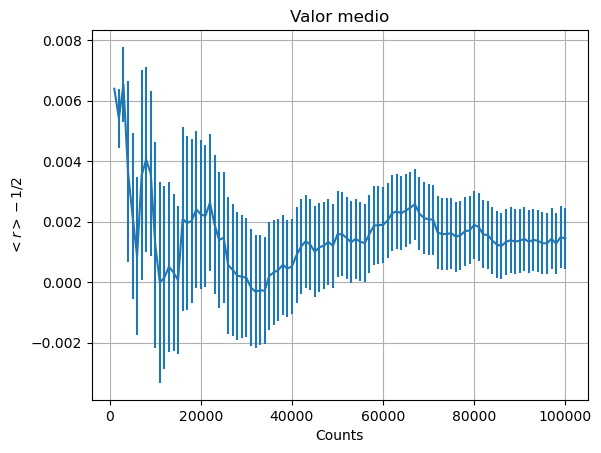

In [3]:
plt.errorbar(n,mean-1/2,mean_err) #plot delle oscillazioni della media (col loro errore) attorno al valore atteso (1/2)

plt.title("Valor medio")
plt.grid(True)
plt.xlabel("Counts")
plt.ylabel(r"$ <r> - 1/2$")
plt.show()

Per l'esercizio 1.1.2, si ottiene il seguente grafico dello scostamento della varianza rispetto al valore atteso (1/12): 

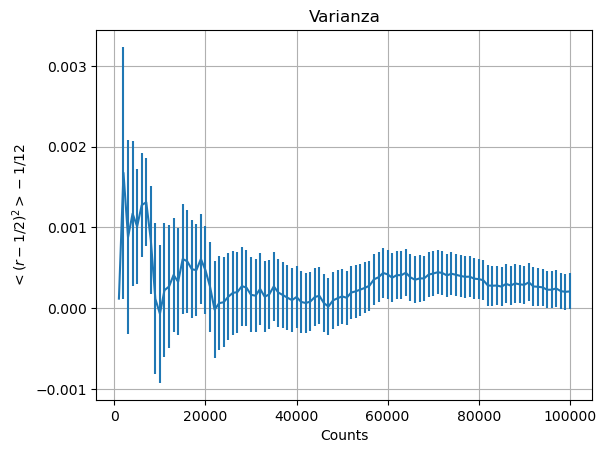

In [4]:


plt.errorbar(n,var-1/12,var_err)#plot delle oscillazioni della varianza (col loro errore) attorno al valore atteso (1/12)

plt.title("Varianza")
plt.grid(True)
plt.xlabel("Counts")
plt.ylabel(r"$ <(r-1/2)^2>-1/12$")
plt.show()

### <span style="color:DodgerBlue"> Esercizio 1.1.3 </span>



Il valore medio di X^2 calcolato è:  99.146796  +- 13.992755401792172


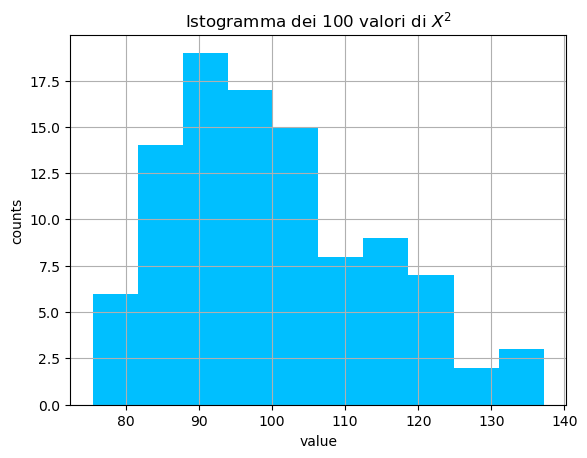

In [5]:


M=100 #numero sottointervalli
n=10000 #numero blocchi
R=100 #numero test


chi_square=np.loadtxt("es_1_3/results.csv",delimiter=",",unpack=True,skiprows=1)



#Mostra l'istogramma dei primi 100 valori di chi_quadro calcolati
plt.hist(chi_square[:100],density=False,color="deepskyblue")
plt.title(rf"Istogramma dei {R} valori di $X^2$")
plt.xlabel("value")
plt.ylabel("counts")
plt.grid(True)

print("Il valore medio di X^2 calcolato è: ", chi_square.mean() ," +-" , chi_square.std())


Il valore medio di $X^2$ calcolato è circa pari al numero di gradi di libertà (100 sottointervalli -> 100 $n_i$ , col vincolo $n=\sum_i n_i$ ). Ciò indica un buon accordo con la previsione teorica. Nella cella sottostante si mette a confronto l'istogramma di dati valori di $X^2$ con la distribuzione teorica di $X^2$.

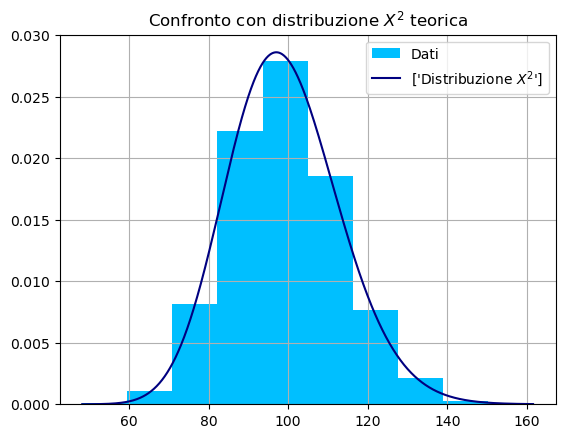

In [6]:


#mostra l'istogramma (con area normalizzata ad 1 ) di 10000 valori di chi_quadro per confronto con distribuzione teorica
min=chi_square.min()
max=chi_square.max()
x=np.linspace(min,max,1000)
plt.hist(chi_square,density=True,label="Dati",color="deepskyblue") 
plt.plot(x,stats.chi2.pdf(x,M-1),label=[r"Distribuzione $X^2$"],color="navy") #distribuzione teorica (df=M-1)
plt.title(rf"Confronto con distribuzione $X^2$ teorica")
plt.legend()
plt.grid(True)

plt.show()

### <span style="color:DodgerBlue"> Esercizio 1.2 </span>



Per tre distribuzioni: uniforme su [0,1],esponenziale ( $\lambda=1$) e lorentziana ($\Gamma=1, \mu=0$), si calcola la media di N valori estratti, con N=1,2,10,100. 

In [7]:

N={0:1,1:2,2:10,3:100}#numero di valori che concorrono alla media

### Distribuzione uniforme

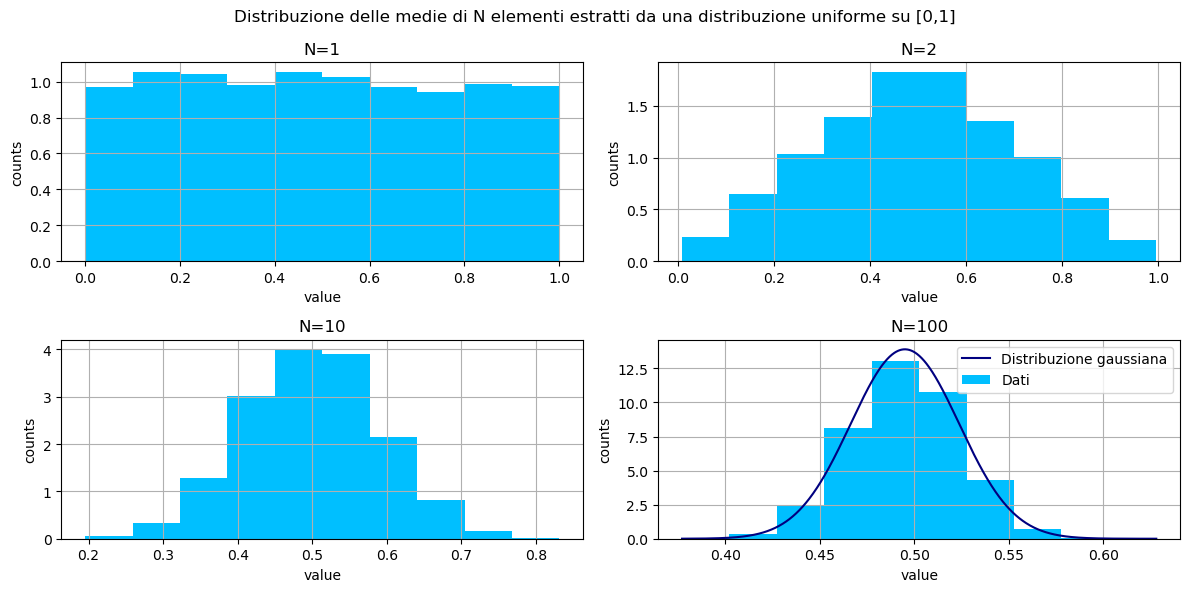

In [8]:
#Distribuzione uniforme

data=np.loadtxt("es_2/res_uni_dist.csv",delimiter=",",unpack=False, skiprows=1)

fig,axs=plt.subplots(2,2,figsize=[12,6]) 

for i,ax in enumerate(axs.flat):
    ax.hist(data[:,i],density=True,color="deepskyblue") #plot della distribuzione, con area normalizzata a 1 
    ax.set_title(f"N={N[i]}")
    ax.set_xlabel("value")
    ax.set_ylabel("counts")
    ax.grid()

#per N=100, confronto con distribuzione gaussiana
mean=data[:,3].mean()
stdv=data[:,3].std()
max=data[:,3].max()
min=data[:,3].min()
x=np.linspace(min,max,1000) 
gauss=stats.norm.pdf(x,loc=mean,scale=stdv) #distribuzione gaussiana
axs[1,1].plot(x,gauss,color="navy")
axs[1,1].legend(["Distribuzione gaussiana","Dati"])


fig.suptitle("Distribuzione delle medie di N elementi estratti da una distribuzione uniforme su [0,1]")
plt.tight_layout()
plt.show()



La distribuzione uniforme ha varianza finita. Per N variabili tratte da essa vale quindi il teorema del limite centrale e la distribuzione delle medie tende, per $N\to +\infty$ , a una gaussiana con valore medio pari alla media dei dati (1/2) e varianza pari alla varianza dei dati ($1/12$) diviso N. 

Nel IV quadrante della figura sopra si può vedere il confronto tra l'istogramma delle medie di 100 valori e la distribuzione gaussiana (con valore medio e varianza ricavati dai dati).

### Distribuzione esponenziale

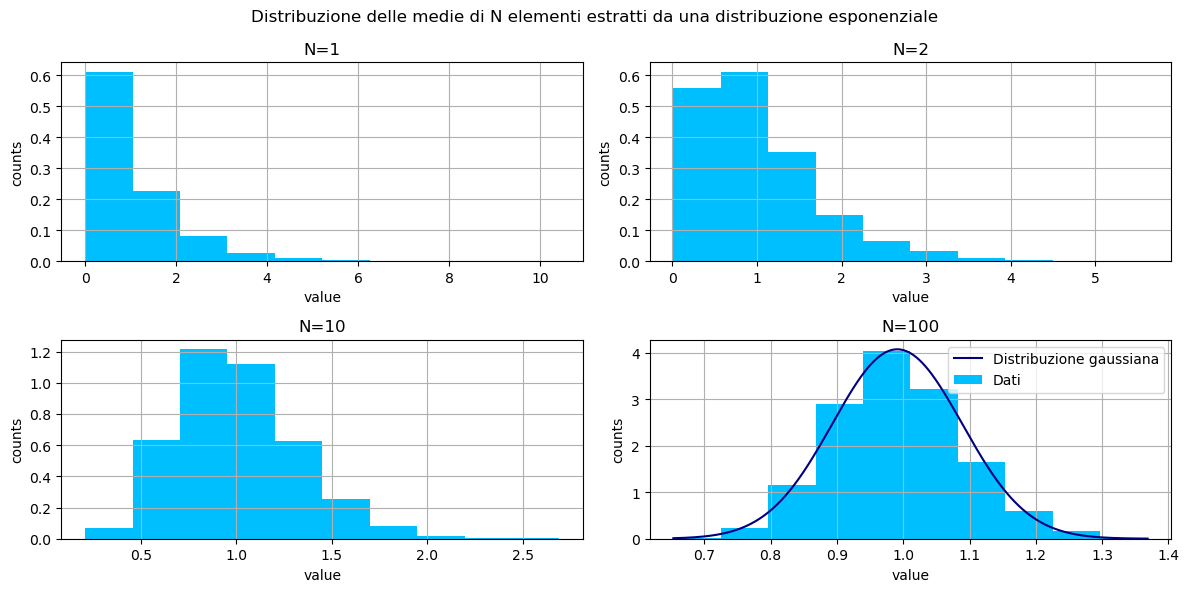

In [9]:

#Distribuzione esponenziale

data=np.loadtxt("es_2/res_exp_dist.csv",delimiter=",",unpack=False, skiprows=1)


fig,axs=plt.subplots(2,2,figsize=[12,6]) 

for i,ax in enumerate(axs.flat):
    ax.hist(data[:,i],density=True,color="deepskyblue") #plot della distribuzione, con area normalizzata a 1 
    ax.set_title(f"N={N[i]}")
    ax.set_xlabel("value")
    ax.set_ylabel("counts")
    ax.grid()

#per N=100, confronto con distribuzione gaussiana
mean=data[:,3].mean()
stdv=data[:,3].std()
max=data[:,3].max()
min=data[:,3].min()
x=np.linspace(min,max,1000) 
gauss=stats.norm.pdf(x,loc=mean,scale=stdv) #distribuzione gaussiana
axs[1,1].plot(x,gauss,color="navy")
axs[1,1].legend(["Distribuzione gaussiana","Dati"])

fig.suptitle("Distribuzione delle medie di N elementi estratti da una distribuzione esponenziale")
plt.tight_layout()
plt.show()


Anche la distribuzione esponenziale ha varianza finita e  vale il teorema del limite centrale.

Nel IV quadrante della figura sopra si può vedere il confronto tra l'istogramma delle medie di 100 valori e la distribuzione gaussiana (con valore medio e varianza ricavati dai dati).

### Distribuzione lorentziana

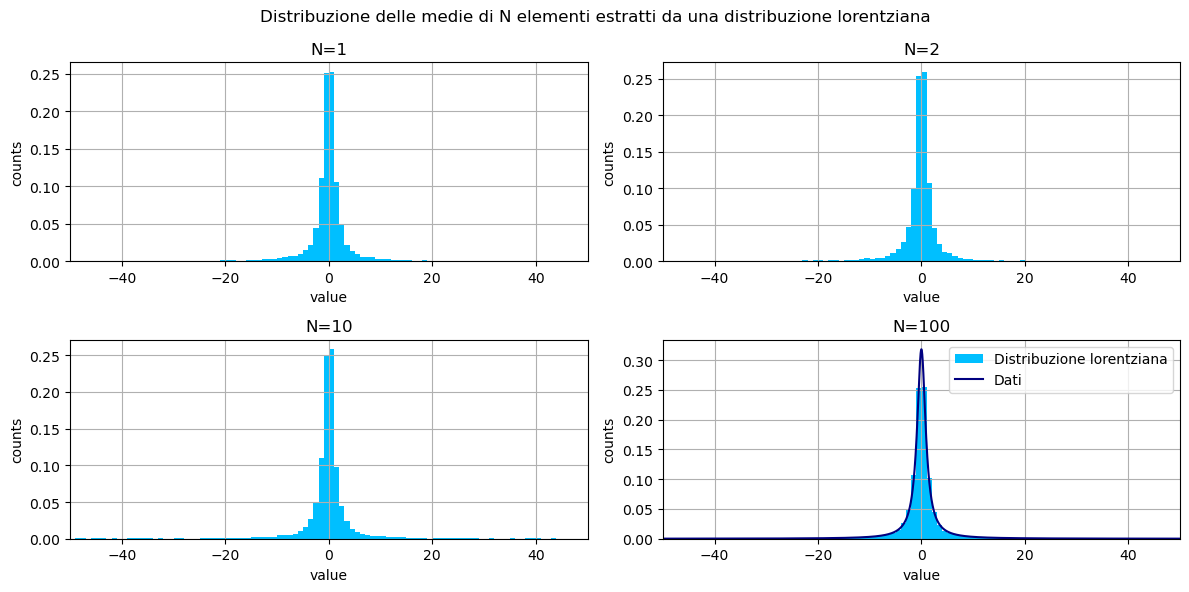

In [10]:

#Distribuzione lorentziana 

data=np.loadtxt("es_2/res_lor_dist.csv",delimiter=",",unpack=False, skiprows=1)


fig,axs=plt.subplots(2,2,figsize=[12,6]) 

#limiti per tagliare le code
min=-50
max=50


for i,ax in enumerate(axs.flat):
    counts, bins = np.histogram(data[:,i],bins=100,range=(min,max),density=True) #crea un istogramma dei dati, tagliando le code
    ax.stairs(counts, bins,fill=True, color="deepskyblue") #plotta l'istogramma creato
    #ax.hist(data[:,i],density=True,histtype="stepfilled",bins=10000,color="deepskyblue") #plot della distribuzione, con area normalizzata a 1
    ax.set_title(f"N={N[i]}")
    ax.set_xlabel("value")
    ax.set_ylabel("counts")
    ax.set_xlim([min,max])
    ax.grid()
  

#per N=100, confronto con distribuzione lorentziana
x=np.linspace(min,max,(max-min)*100) 
lor=stats.cauchy.pdf(x,loc=0,scale=1)#distribuzione lorentziana
axs[1,1].plot(x,lor,color="navy")
axs[1,1].legend(["Distribuzione lorentziana","Dati"])

fig.suptitle("Distribuzione delle medie di N elementi estratti da una distribuzione lorentziana")
plt.tight_layout()
plt.show()






La distribuzione lorentziana non ha varianza finita, e quindi non è possibile utilizzare il teorema del limite centrale. Però è stabile: difatti la distribuzione della media di N variabili indipendenti estratte da una distribuzione lorentziana con parametri $\Gamma, \mu$  è ancora una lorentziana con gli stessi $\Gamma, \mu$ .

Date le code molto lunghe della distribuzione lorentziana, per osservare questo fenomeno si è reso necessario limitare il range dei dati considerati.

### <span style="color:DodgerBlue"> Esercizio 1.3 </span>



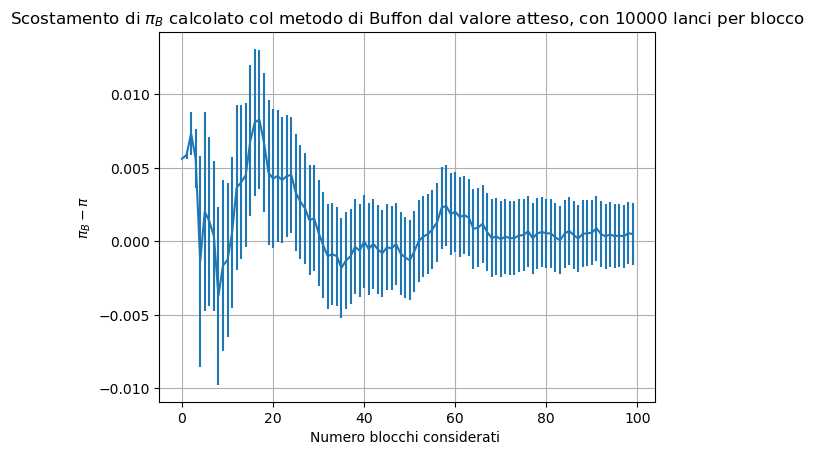

In [11]:
M=10000 #numero lanci per blocco
N=100 #numero blocchi

mean,error=np.loadtxt("es_3/results.csv", usecols=(0,1), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(N) #progressivo dei blocchi
plt.errorbar(n,mean-np.pi,error) 

plt.title(fr"Scostamento di $\pi_B$ calcolato col metodo di Buffon dal valore atteso, con {M} lanci per blocco")
plt.xlabel("Numero blocchi considerati ")
plt.ylabel(rf"$\pi_B - \pi$")
plt.grid(True)
plt.show()